# Fase 2 - Analitica No Supervisada (Spark MLlib)

Segmentacion de jugadores con K-Means, seleccion del numero optimo de clusters, interpretacion de perfiles de negocio y motor de 'jugadores clon'.

In [1]:
import os
os.environ.setdefault('JAVA_HOME', '/opt/homebrew/opt/openjdk@17')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

spark = SparkSession.builder \
    .appName('ScoutingClustering') \
    .master('local[*]') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

df = spark.read.parquet('../data/processed/players_clean.parquet')
print((df.count(), len(df.columns)))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/13 19:22:55 WARN Utils: Your hostname, MacBook-de-Rodrigo.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.2 instead (on interface en0)
26/07/13 19:22:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/13 19:22:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


(91672, 93)


## Preparacion de features

Se usan los atributos tecnicos/fisicos/mentales (escala FM 1-20) como espacio de features para el clustering. Se excluyen atributos de portero (`TRO`, `Ref`, `Pun`, `Cmd`, `Han`, `Aer`, `Com`) para que no dominen la segmentacion de jugadores de campo, ya que su escala no es comparable entre posiciones.

In [2]:
goalkeeper_only_cols = ['TRO', 'Ref', 'Pun', 'Cmd', 'Han', 'Aer', 'Com', '1v1']
attribute_cols = [
    'Acc','Wor','Vis','Thr','Tec','Tea','Tck','Str','Sta','Pos','Pen','Pas','Pac',
    'OtB','Habilidad_Natural','Mar','L Th','Lon','Ldr','Kic','Jum','Hea','Fre','Fla','Fir','Fin','Ecc',
    'Dri','Det','Dec','Cro','Cor','Cnt','Cmp','Bra','Bal','Ant','Agi','Agg','Vers',
    'Temp','Spor','Prof','Pres','Loy','Inj Pr','Imp M','Dirt','Amb','Ada','Cons','Cont',
]

df_field = df.filter(F.col('Position') != 'GK').na.drop(subset=attribute_cols)
print(df_field.count())

assembler = VectorAssembler(inputCols=attribute_cols, outputCol='features_raw')
scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model = prep_pipeline.fit(df_field)
df_scaled = prep_model.transform(df_field).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').cache()
df_scaled.count()

26/07/13 19:22:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


82367


82367

## Seleccion del numero optimo de clusters: metodo del codo + silhouette

In [3]:
evaluator = ClusteringEvaluator(featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')

results = []
for k in range(2, 11):
    km = KMeans(featuresCol='features', k=k, seed=42)
    model = km.fit(df_scaled)
    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)
    inertia = model.summary.trainingCost
    results.append((k, inertia, silhouette))
    print(f"k={k}: inertia={inertia:.1f}, silhouette={silhouette:.4f}")

26/07/13 19:23:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k=2: inertia=3715154.0, silhouette=0.2225


k=3: inertia=3477491.2, silhouette=0.1920


k=4: inertia=3320377.2, silhouette=0.1479


k=5: inertia=3231648.7, silhouette=0.1253


k=6: inertia=3151452.8, silhouette=0.1265


k=7: inertia=3110357.8, silhouette=0.1124


k=8: inertia=3065841.1, silhouette=0.1063


k=9: inertia=3025020.4, silhouette=0.1032


k=10: inertia=2983475.4, silhouette=0.1043


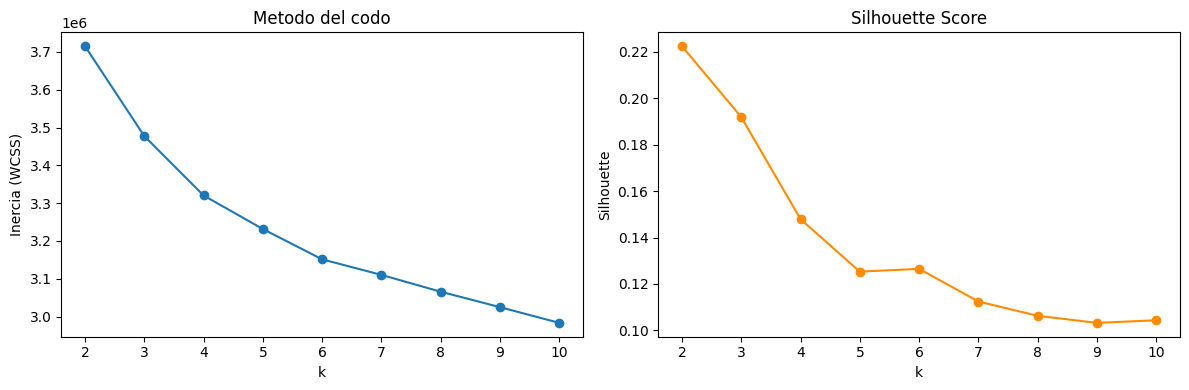

In [4]:
import matplotlib.pyplot as plt

ks = [r[0] for r in results]
inertias = [r[1] for r in results]
silhouettes = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia (WCSS)')

axes[1].plot(ks, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.savefig('../reports/figures/clustering_k_selection.png', dpi=120)
plt.show()

## Entrenamiento del modelo final e interpretacion de clusters

TODO: fijar `K_OPTIMO` segun el codo/silhouette observado arriba antes de continuar.

In [5]:
K_OPTIMO = 5  # ajustar segun el grafico anterior

kmeans_final = KMeans(featuresCol='features', k=K_OPTIMO, seed=42)
final_model = kmeans_final.fit(df_scaled)
clustered = final_model.transform(df_scaled)

clustered.groupBy('prediction').count().orderBy('prediction').show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|18534|
|         1|11581|
|         2|18820|
|         3|11861|
|         4|21571|
+----------+-----+



## Motor de busqueda de 'jugadores clon' (reemplazos de bajo costo)

Dado un jugador de referencia (ej. una superestrella), se buscan los jugadores mas cercanos en el mismo cluster con menor valor de mercado, usando distancia euclidiana y similitud de coseno sobre el vector de features escalado.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import numpy as np
import pandas as pd

def buscar_clones(nombre_referencia, top_n=10):
    ref_row = clustered.filter(F.col('Name') == nombre_referencia).limit(1).collect()
    if not ref_row:
        raise ValueError(f"Jugador '{nombre_referencia}' no encontrado")
    ref_row = ref_row[0]
    ref_cluster = ref_row['prediction']
    ref_vector = np.array(ref_row['features'].toArray()).reshape(1, -1)

    candidatos = clustered.filter(
        (F.col('prediction') == ref_cluster) & (F.col('Name') != nombre_referencia)
    ).select('UID', 'Name', 'Position', 'Transfer_Value_num', 'features').toPandas()

    candidatos_matrix = np.stack(candidatos['features'].apply(lambda v: v.toArray()).to_numpy())

    candidatos['distancia_euclidiana'] = euclidean_distances(candidatos_matrix, ref_vector).flatten()
    candidatos['similitud_coseno'] = cosine_similarity(candidatos_matrix, ref_vector).flatten()

    ref_valor = ref_row['Transfer_Value_num'] or 0
    clones = candidatos[candidatos['Transfer_Value_num'].fillna(0) < ref_valor]
    return clones.sort_values('distancia_euclidiana').head(top_n)[
        ['Name', 'Position', 'Transfer_Value_num', 'distancia_euclidiana', 'similitud_coseno']
    ]

# Ejemplo de uso: reemplazar con un nombre real presente en el dataset
buscar_clones('Kai Havertz')

/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rodrigogalvezarrascue/Proyectos/proyectoBigData/venv/lib/python3.9/site-packages/

,Name,Position,Transfer_Value_num,distancia_euclidiana,similitud_coseno
10215,Gonçalo Ramos,ST (C),15500000.0,6.176485,0.838128
5,Florian Grillitsch,"D (C), DM, M/AM (C)",20000000.0,6.237208,0.831464
7825,Ludovic Blas,"M (C), AM (RC)",12750000.0,6.237275,0.832918
9575,Pedri,"M (C), AM (RLC)",110000000.0,6.309208,0.838949
9254,Ferran Torres,"AM (RL), ST (C)",81000000.0,6.311818,0.828946
1188,Martin Terrier,"AM (RLC), ST (C)",32000000.0,6.312012,0.828724
7245,Martin Terrier,"AM (RLC), ST (C)",32000000.0,6.312012,0.828724
3848,Roberto Firmino,"AM (RLC), ST (C)",53000000.0,6.337514,0.836553
10219,Vanderson,D/WB/M (R),29500000.0,6.523978,0.818332
8651,Alessio Zerbin,"AM (RL), ST (C)",2150000.0,6.526847,0.820687
